# EDA and Text Preprocessing - Urgency Classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from google.colab import drive

# Menautkan Google Drive ke dalam sesi Colab
drive.mount('/content/drive')

# Mendefinisikan jalur absolut menuju direktori root proyek Anda di Drive
# Sesuaikan 'MyDrive/lentera-ml-research' dengan lokasi folder Anda di Drive
PROJECT_ROOT = '/content/drive/MyDrive/lentera-analytics-hub/lentera-ml-research'

# Mengubah direktori kerja (Current Working Directory) agar kernel berada di root
os.chdir(PROJECT_ROOT)
print(f"Direktori aktif saat ini: {os.getcwd()}")

# Memasukkan direktori root proyek ke dalam sistem pencarian modul Python
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    
# mengambil path dari direktori root project
root_path = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Memasukkan jalur root ke dalam pencarian modul Python
if root_path not in sys.path:
    sys.path.append(root_path)

# Styling for plots
sns.set_theme(style="whitegrid")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Direktori aktif saat ini: /content/drive/MyDrive/lentera-analytics-hub/lentera-ml-research


## 1. Load Data

In [2]:
dataset_path = 'data/raw/complaints-2026-05-20_09_21.csv'
df = pd.read_csv(dataset_path)
print(f"Shape of dataset: {df.shape}")
df.head(2)

Shape of dataset: (53928, 18)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,03/17/26,Debt collection,Auto debt,Written notification about debt,Didn't receive notice of right to dispute,I started getting emails and telephone calls f...,NaN,"The Bureaus, Inc.",GA,30518,NaN,Consent provided,Web,03/17/26,Closed with explanation,Yes,NaN,20323715
1,03/05/26,Debt collection,Other debt,False statements or representation,Attempted to collect wrong amount,Date : XX/XX/XXXX To : XXXX XXXX Re : XXXXXXXX...,NaN,"CAINE & WEINER COMPANY, INC.",OR,973XX,NaN,Consent provided,Web,03/19/26,Closed with non-monetary relief,Yes,NaN,20012076


## 2. Pembersihan Data Awal
Menghapus baris jika:
1. `Consumer complaint narrative` kosong (NaN).
2. `Consumer complaint narrative` hanya berisi karakter aneh atau panjang katanya kurang dari 3 kata.

In [3]:
from src.preprocessing import filter_invalid_complaints

df = filter_invalid_complaints(df)
print(f"Dimensi data setelah pembersihan awal: {df.shape}")

Dimensi data setelah pembersihan awal: (53928, 19)


## 3. Auto Labeling Urgency

In [4]:
from src.preprocessing import apply_urgency_labels

df = apply_urgency_labels(df)

# Cek distribusi kelas
print("Distribusi Urgency:")
print(df['Urgency'].value_counts())

Distribusi Urgency:
Urgency
Medium    26300
High      20771
Low        6857
Name: count, dtype: int64


## 5. Text Preprocessing
Membersihkan `Consumer complaint narrative` untuk persiapan *training* model Deep Learning.
Tahapan:
1. Lowercasing
2. Menghapus karakter anonimitas dari data CFPB (seperti `XXXX`, `XX/XX/XXXX`)
3. Menghapus tanda baca dan angka
4. Menghapus *stopwords*

In [5]:
from src.preprocessing import normalize_text_pipeline

df = normalize_text_pipeline(df)

## 4. Exploratory Data Analysis (EDA)
Melihat distribusi kelas dan distribusi panjang kata per kelas.

/tmp/ipykernel_12096/1184275637.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Urgency', data=df, order=['High', 'Medium', 'Low'], palette='viridis')


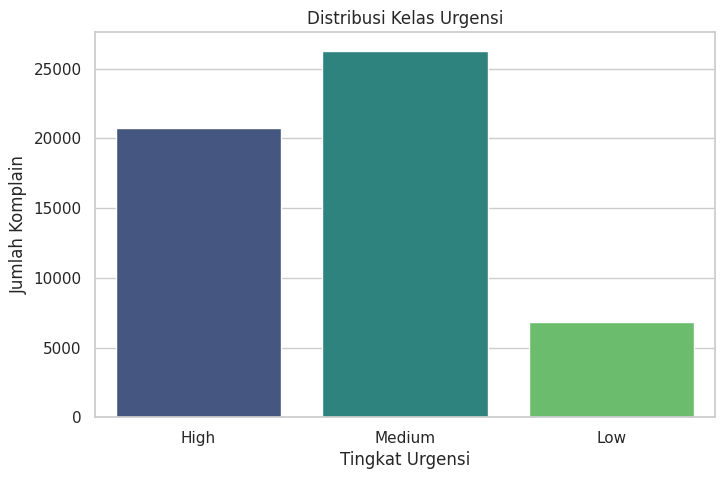

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Urgency', data=df, order=['High', 'Medium', 'Low'], palette='viridis')
plt.title('Distribusi Kelas Urgensi')
plt.ylabel('Jumlah Komplain')
plt.xlabel('Tingkat Urgensi')
plt.show()

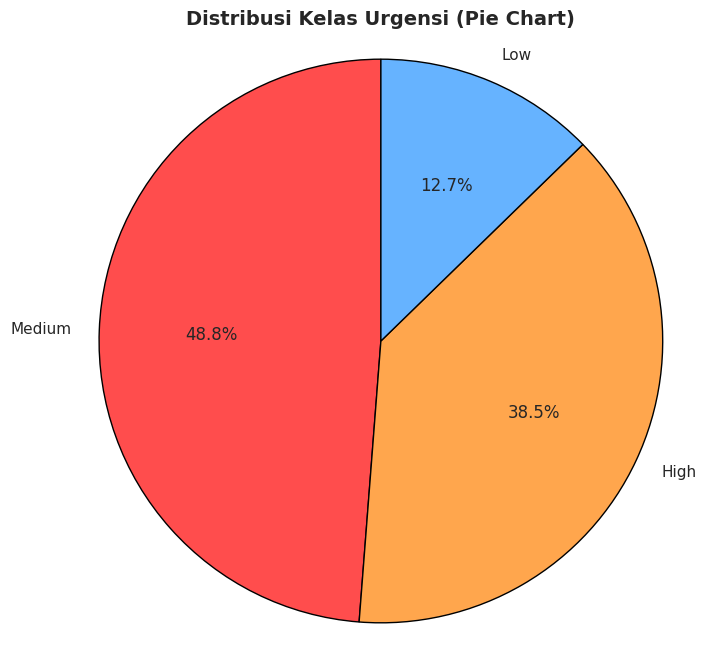

In [7]:
# Pie Chart Distribusi Kelas Urgensi
plt.figure(figsize=(8, 8))
class_counts = df['Urgency'].value_counts()
colors = ['#ff4d4d', '#ffa64d', '#66b3ff']
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops={'edgecolor': 'black'})
plt.title('Distribusi Kelas Urgensi (Pie Chart)', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

/tmp/ipykernel_12096/1069594578.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Urgency', y='Word Count', data=df, order=['High', 'Medium', 'Low'], palette='Set2')


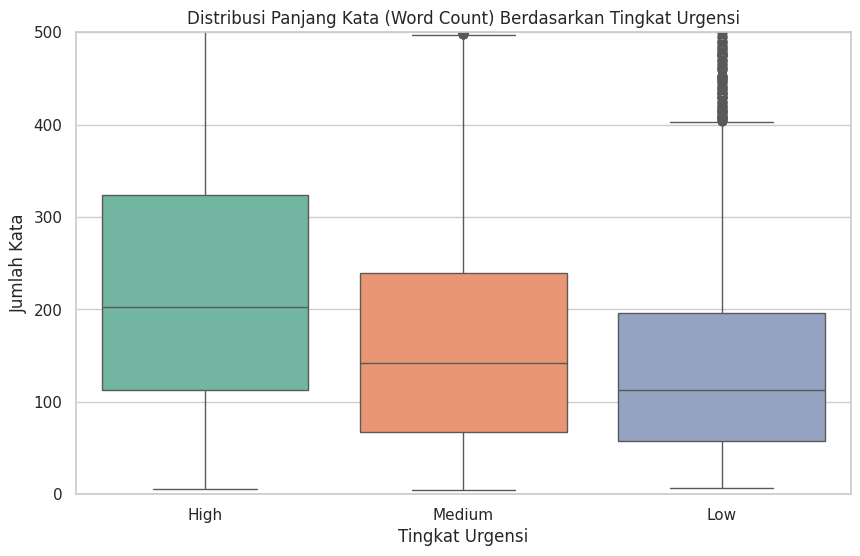

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Urgency', y='Word Count', data=df, order=['High', 'Medium', 'Low'], palette='Set2')
plt.title('Distribusi Panjang Kata (Word Count) Berdasarkan Tingkat Urgensi')
plt.ylim(0, 500) # Membatasi visualisasi outlier ekstrem agar lebih jelas 
plt.ylabel('Jumlah Kata')
plt.xlabel('Tingkat Urgensi')
plt.show()

## 6. EDA (NLP Insights)

### Analisis N-Gram (Bigram)

Memproses Bigram Analysis...


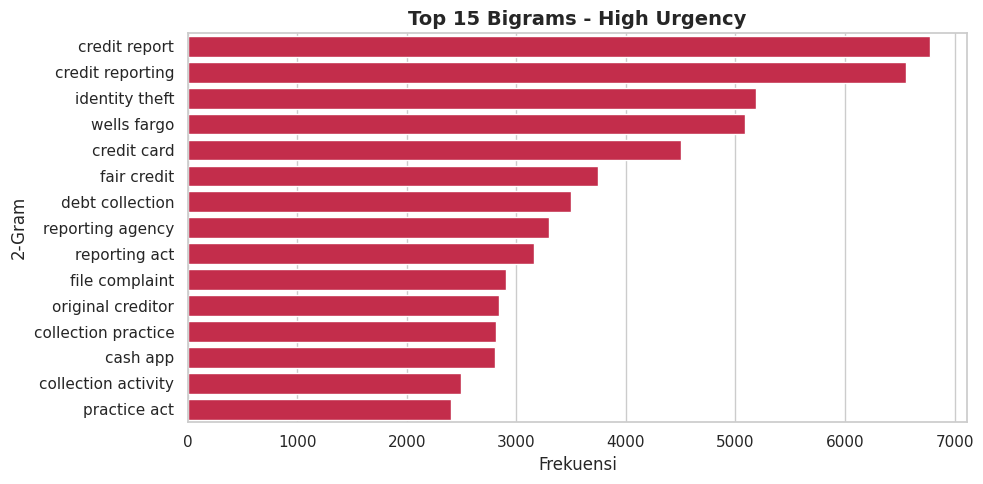

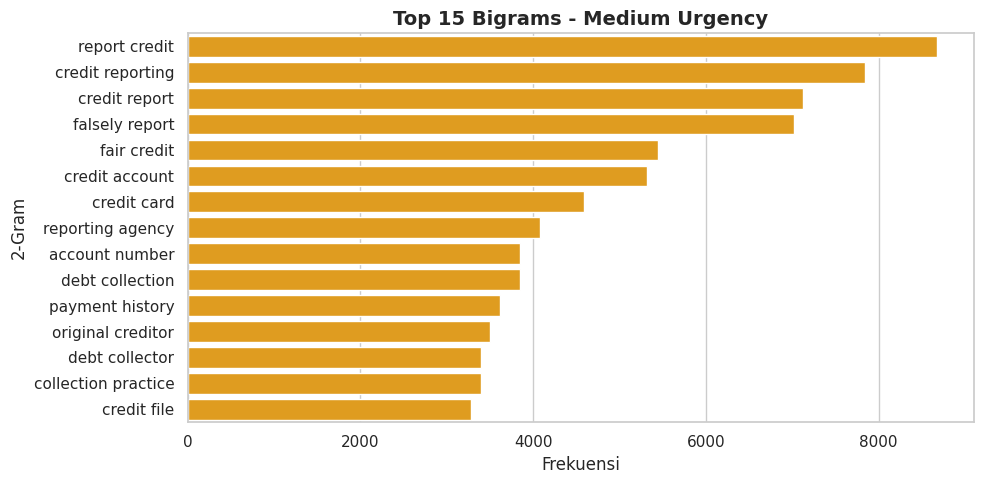

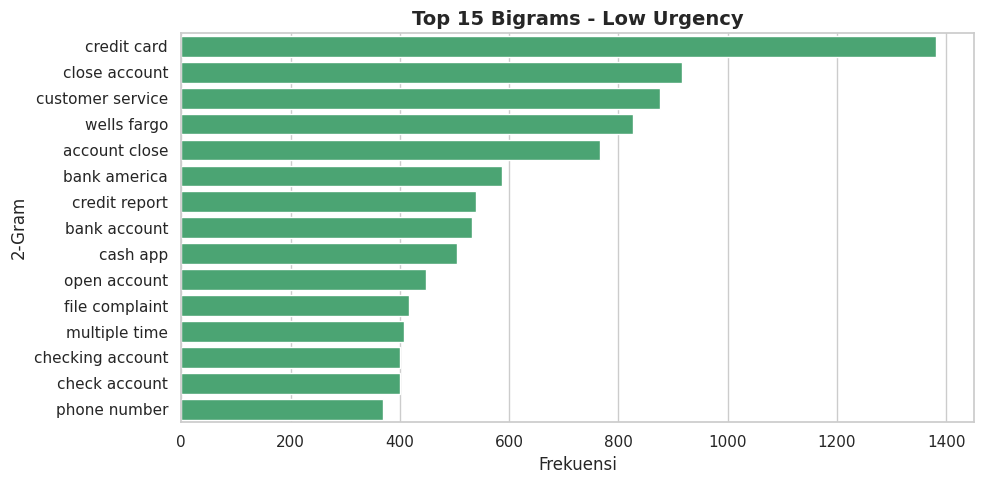

In [9]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

# Fungsi untuk mengekstrak dan memplot top N-Grams
def plot_top_ngrams(text_series, n, title, color):
    # Inisialisasi CountVectorizer untuk N-Gram (n=2 untuk Bigram)
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(text_series)
    bag_of_words = vec.transform(text_series)
    sum_words = bag_of_words.sum(axis=0) 
    
    # Mengurutkan frekuensi kata dari yang tertinggi
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:15]
    
    # Membuat DataFrame untuk visualisasi
    df_ngram = pd.DataFrame(words_freq, columns=['N-Gram', 'Frekuensi'])
    
    # Plotting menggunakan Seaborn
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Frekuensi', y='N-Gram', data=df_ngram, color=color)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Frekuensi', fontsize=12)
    plt.ylabel(f'{n}-Gram', fontsize=12)
    plt.tight_layout()
    plt.show()

# Memisahkan data berdasarkan kelas urgensi
high_texts = df[df['Urgency'] == 'High']['Cleaned_Narrative']
medium_texts = df[df['Urgency'] == 'Medium']['Cleaned_Narrative']
low_texts = df[df['Urgency'] == 'Low']['Cleaned_Narrative']

# Mengeksekusi fungsi untuk masing-masing kelas (Bigram / 2 kata)
print("Memproses Bigram Analysis...")
plot_top_ngrams(high_texts, 2, 'Top 15 Bigrams - High Urgency', 'crimson')
plot_top_ngrams(medium_texts, 2, 'Top 15 Bigrams - Medium Urgency', 'orange')
plot_top_ngrams(low_texts, 2, 'Top 15 Bigrams - Low Urgency', 'mediumseagreen')

### Word Cloud Tingkat Urgensi

Memproses Word Cloud...


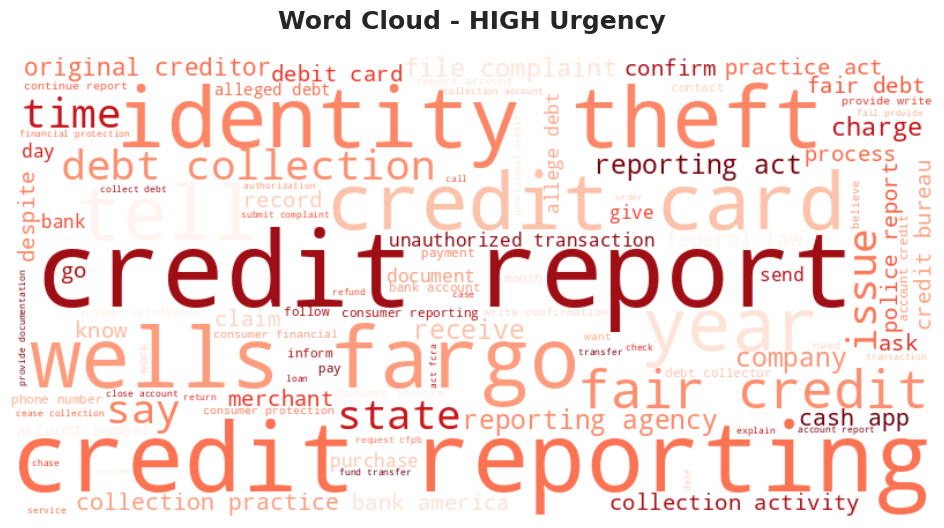

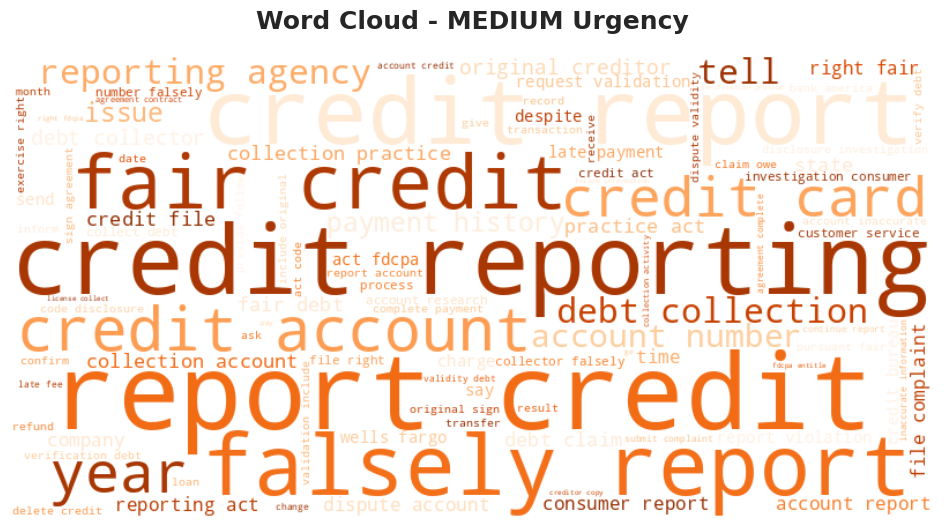

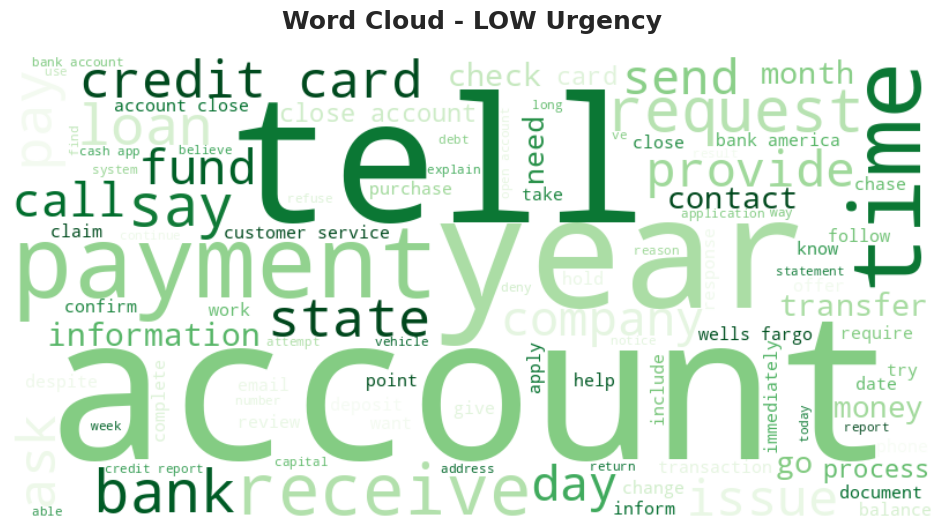

In [10]:
from wordcloud import WordCloud

# Fungsi untuk membuat dan memplot Word Cloud
def plot_wordcloud(text_series, title, colormap):
    # Menggabungkan semua baris teks menjadi satu paragraf raksasa
    text = " ".join(text_series.astype(str))
    
    # Membuat WordCloud dengan parameter visual
    wordcloud = WordCloud(width=800, height=400, 
                          background_color='white', 
                          colormap=colormap, 
                          max_words=100,
                          contour_width=3, 
                          contour_color='steelblue').generate(text)
    
    # Plotting
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=18, fontweight='bold', pad=20)
    plt.show()

# Mengeksekusi Word Cloud dengan warna yang mencerminkan urgensi
print("Memproses Word Cloud...")
plot_wordcloud(high_texts, 'Word Cloud - HIGH Urgency', 'Reds')
plot_wordcloud(medium_texts, 'Word Cloud - MEDIUM Urgency', 'Oranges')
plot_wordcloud(low_texts, 'Word Cloud - LOW Urgency', 'Greens')

## 7. Menyimpan Data Bersih (Final Dataset)
Membuat *subset* dataset (Hanya berisi Fitur dan Label Target) kemudian menyimpannya ke `.csv` baru agar di tahapan *Training* (Notebook berikutnya).

In [11]:
# 1. Hapus baris kosong yang mungkin tersisa
df = df.dropna(subset=['Cleaned_Narrative', 'Raw_Filtered_Narrative'])

# 2. Pastikan teks tidak murni berisi spasi kosong pasca-pembersihan
df = df[df['Cleaned_Narrative'].str.strip() != '']

# 3. Sertakan KEDUA varian teks berserta label target
df_final = df[['Raw_Filtered_Narrative', 'Cleaned_Narrative', 'Urgency']].copy()

# 4. Ekspor dataset yang telah siap didistribusikan ke tim
df_final.to_csv('data/processed/cleaned_complaints.csv', index=False)

print(f"Dimensi dataset siap pakai: {df_final.shape}")
print(df_final.head(3))

Dimensi dataset siap pakai: (53927, 3)
                              Raw_Filtered_Narrative  \
0  i started getting emails and telephone calls f...   
1  date : // to : re : ref bal : {$1000.00} ep au...   
2  i was approached by a group of people outside ...   

                                   Cleaned_Narrative Urgency  
0  start get email telephone call company call bu...     Low  
1  date ref bal ep audit continue contact cease d...    High  
2  approach group people outside local grocery st...    High  
